In [28]:
# ============================================================
# 1. Install required libraries
# ============================================================

!uv pip install kagglehub tensorflow matplotlib numpy opencv-python pillow rembg
!uv pip install "rembg[cpu]" --quiet

Using Python 3.11.14 environment at: /Users/kevin/Desktop/engineer/ai-engineer/deep-learning/.venv
Audited 7 packages in 33ms


In [2]:
# ============================================================
# 2. Download PlantVillage dataset
# ============================================================

import kagglehub

path = kagglehub.dataset_download("arjuntejaswi/plant-village")

/Users/kevin/Desktop/engineer/ai-engineer/deep-learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================
# 3. Imports
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import models, layers

In [4]:
# ============================================================
# 4. Basic configuration
# ============================================================

print(f"Path: {path}")
print(f"Contents of path: {os.listdir(path)}")

DIRECTORY = f"{path}/PlantVillage/"

IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
VERBOSE = 1
EPOCHS = 10

Path: /Users/kevin/.cache/kagglehub/datasets/arjuntejaswi/plant-village/versions/1
Contents of path: ['PlantVillage']


In [5]:
# ============================================================
# 5. Load dataset
# ============================================================

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DIRECTORY,
    seed=42,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names

print("Classes:")
print(class_names)
print("Number of classes:", len(class_names))
print("Number of batches:", len(dataset))

Found 20638 files belonging to 15 classes.
Classes:
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 15
Number of batches: 645


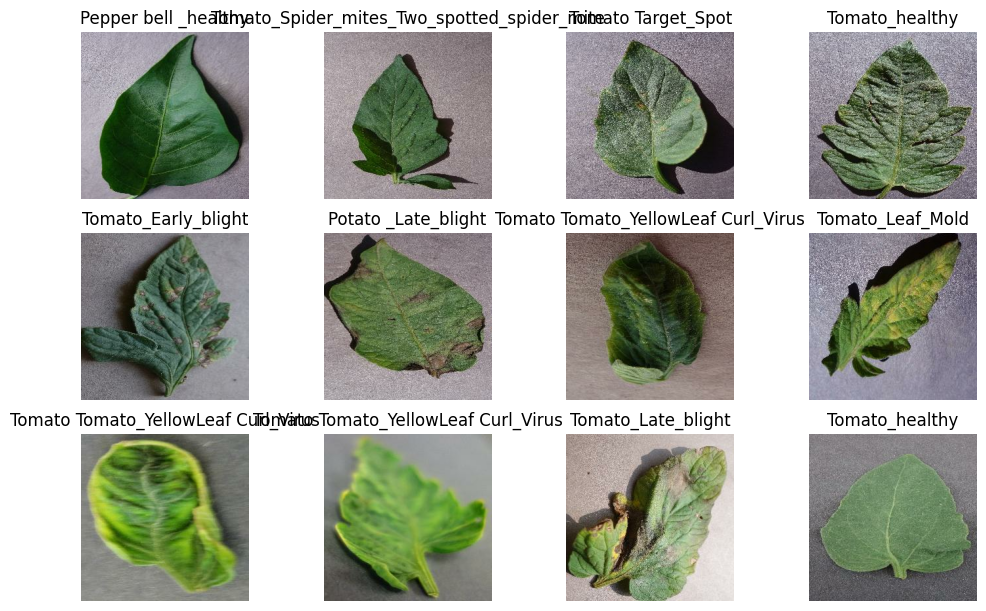

In [6]:
# ============================================================
# 6. Show sample images
# ============================================================

for image_batch, label_batch in dataset.take(1):
    plt.figure(figsize=(12, 10))

    for idx in range(12):
        ax = plt.subplot(4, 4, idx + 1)
        plt.imshow(image_batch[idx].numpy().astype("uint8"))
        plt.title(class_names[label_batch[idx].numpy()].replace("__", " "))
        plt.axis("off")

    plt.show()

In [7]:
# ============================================================
# 7. Split dataset into train, validation, test
# ============================================================

def get_dataset_partitions_tf(
    ds,
    train_split=0.8,
    val_split=0.1,
    test_split=0.1,
    shuffle=True,
    shuffle_size=10000
):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=42)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds


train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

Train batches: 516
Validation batches: 64
Test batches: 65


In [8]:
# ============================================================
# 8. Optimize dataset loading
# ============================================================

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [9]:
# ============================================================
# 9. Preprocessing and augmentation
# ============================================================

resize_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
], name="resize_rescale")

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
], name="data_augmentation")

In [10]:
# ============================================================
# 10. Build CNN model
# ============================================================

n_classes = len(class_names)

model = models.Sequential([
    layers.InputLayer(input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),

    resize_rescale,
    data_augmentation,

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", name="conv_1"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", name="conv_2"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", name="conv_3"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", name="conv_4"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", name="conv_5"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model.summary()

/Users/kevin/Desktop/engineer/ai-engineer/deep-learning/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resize_rescale (Sequential)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_5 (Conv2D)                 │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,671 (1.06 MB)

 Trainable params: 278,671 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ============================================================
# 11. Compile model
# ============================================================

model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [12]:
# ============================================================
# 12. Create model folder and callbacks
# ============================================================

os.makedirs("./models", exist_ok=True)

version = len(os.listdir("./models")) + 1

callbacks = [
    keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        patience=3
    ),
    keras.callbacks.ModelCheckpoint(
        f"./models/plant_village_v{version}.keras",
        save_best_only=True
    )
]

In [13]:
# ============================================================
# 13. Train model
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    verbose=VERBOSE,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 192s 365ms/step - accuracy: 0.4127 - loss: 1.8136 - val_accuracy: 0.5708 - val_loss: 1.3150 - learning_rate: 0.0010
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 193s 374ms/step - accuracy: 0.7124 - loss: 0.8543 - val_accuracy: 0.6450 - val_loss: 1.2139 - learning_rate: 0.0010
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 203s 393ms/step - accuracy: 0.7762 - loss: 0.6521 - val_accuracy: 0.6191 - val_loss: 1.3292 - learning_rate: 0.0010
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 188s 365ms/step - accuracy: 0.8211 - loss: 0.5168 - val_accuracy: 0.7773 - val_loss: 0.7271 - learning_rate: 0.0010
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 179s 346ms/step - accuracy: 0.8485 - loss: 0.4386 - val_accuracy: 0.7983 - val_loss: 0.6512 - learning_rate: 0.0010
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 178s 344ms/step - accuracy: 0.8631 - loss: 0.3988 - val_accuracy: 0.7725 - val_loss: 0.7249 - learning_rate: 0.0010
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 189s 367ms/step - accura

In [14]:
# ============================================================
# 14. Evaluate model
# ============================================================

scores = model.evaluate(test_ds)

print("Test loss:", scores[0])
print("Test accuracy:", scores[1])

65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - accuracy: 0.8880 - loss: 0.3095
Test loss: 0.3094634711742401
Test accuracy: 0.8879807591438293


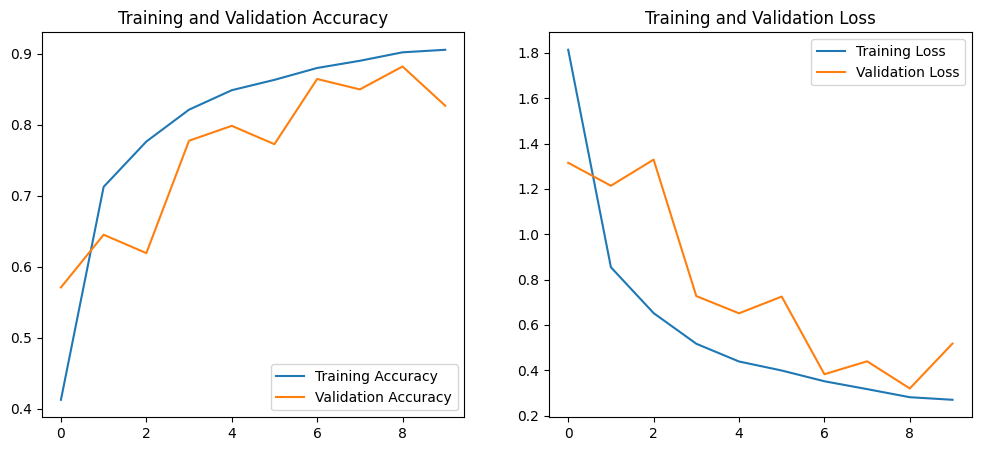

In [15]:
# ============================================================
# 15. Plot training accuracy and loss
# ============================================================

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(accuracy))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
Actual label:      Tomato__Tomato_YellowLeaf__Curl_Virus
Predicted label:   Tomato__Tomato_YellowLeaf__Curl_Virus
Confidence:       99.97%
Correct: True


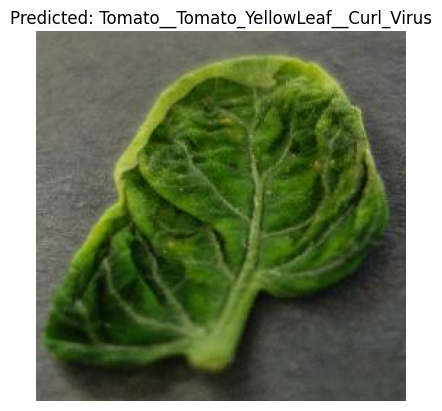

In [16]:
# ============================================================
# 16. Simple prediction on test image
# ============================================================

for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype("uint8")
    first_label = labels_batch[0].numpy()

    batch_prediction = model.predict(images_batch)

    actual_label = class_names[first_label]
    predicted_label = class_names[np.argmax(batch_prediction[0])]
    confidence = np.max(batch_prediction[0]) * 100

    print("Actual label:     ", actual_label)
    print("Predicted label:  ", predicted_label)
    print(f"Confidence:       {confidence:.2f}%")
    print("Correct:", actual_label == predicted_label)

    plt.imshow(first_image)
    plt.title(f"Predicted: {predicted_label}")
    plt.axis("off")
    plt.show()

In [17]:
# ============================================================
# 17. Find last convolution layer
# ============================================================

def find_last_conv_layer(model):
    """
    Finds the last Conv2D layer in the model.
    Grad-CAM needs the last convolution layer.
    """
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

    raise ValueError("No Conv2D layer found in the model.")


last_conv_layer_name = find_last_conv_layer(model)

print("Last convolution layer:", last_conv_layer_name)

Last convolution layer: conv_5


In [18]:
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.outputs[0]
    ]
)


In [19]:
# ============================================================
# 18. Grad-CAM heatmap function
# ============================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Creates Grad-CAM heatmap.

    img_array shape:
        (1, 256, 256, 3)

    Important:
        Do not divide image by 255 here because your model already contains
        the Rescaling layer.
    """

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    heatmap = heatmap / (max_value + 1e-8)

    return heatmap.numpy(), predictions.numpy()[0]

In [20]:
# ============================================================
# 19. Mark diseased / rotted area on leaf
# ============================================================

def mark_diseased_area(image, heatmap, threshold=0.45):
    """
    Marks likely diseased area using Grad-CAM heatmap.

    image:
        RGB image of shape (256, 256, 3)

    heatmap:
        Grad-CAM heatmap

    threshold:
        Controls how much area is marked.
        Lower threshold = more area marked.
        Higher threshold = less area marked.
    """

    image = image.astype("uint8")

    h, w = image.shape[:2]

    # Resize heatmap to original image size
    heatmap_resized = cv2.resize(heatmap, (w, h))

    # Create binary mask from heatmap
    mask = heatmap_resized >= threshold
    mask_uint8 = np.uint8(mask) * 255

    # Clean mask slightly
    kernel = np.ones((5, 5), np.uint8)

    mask_uint8 = cv2.morphologyEx(
        mask_uint8,
        cv2.MORPH_OPEN,
        kernel
    )

    mask_uint8 = cv2.morphologyEx(
        mask_uint8,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Find contours of highlighted region
    contours, _ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Convert heatmap to color
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized),
        cv2.COLORMAP_JET
    )

    # Convert RGB image to BGR for OpenCV
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # Overlay heatmap on original image
    overlay = cv2.addWeighted(
        image_bgr,
        0.60,
        heatmap_colored,
        0.40,
        0
    )

    # Minimum contour area to ignore small noise
    min_area = 0.005 * h * w

    for contour in contours:
        area = cv2.contourArea(contour)

        if area > min_area:
            # Draw green contour around suspected diseased region
            cv2.drawContours(
                overlay,
                [contour],
                -1,
                (0, 255, 0),
                2
            )

            # Draw white rectangle around region
            x, y, cw, ch = cv2.boundingRect(contour)

            cv2.rectangle(
                overlay,
                (x, y),
                (x + cw, y + ch),
                (255, 255, 255),
                2
            )

    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    return overlay_rgb, heatmap_resized, mask_uint8

In [21]:
# ============================================================
# 20. Full function: predict disease and mark affected area
# ============================================================

def predict_and_mark_disease_area(image, model, class_names, threshold=0.45, confidence_threshold=0.80):
    """
    Takes one image and returns prediction with optional Grad-CAM marking.
    
    Only generates heatmaps and marks diseased areas when:
    1. Confidence is above confidence_threshold
    2. Predicted class is NOT "Healthy"
    
    Args:
        image: Input image
        model: Trained model
        class_names: List of class names
        threshold: GradCAM threshold (0-1)
        confidence_threshold: Only mark disease if confidence > this value (default 0.80)
    
    Returns:
        Dictionary with prediction results and optional markings
    """

    image = image.astype("uint8")
    img_array = np.expand_dims(image, axis=0)

    heatmap, predictions = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    predicted_idx = np.argmax(predictions)
    predicted_label = class_names[predicted_idx]
    confidence = predictions[predicted_idx]

    result = {
        "original_image": image,
        "predicted_label": predicted_label,
        "confidence": confidence * 100,
        "heatmap": None,
        "mask": None,
        "marked_image": image.copy(),
        "is_healthy": "healthy" in predicted_label.lower(),
        "high_confidence": confidence > confidence_threshold
    }
    
    # Only generate heatmap and mark if:
    # 1. Confidence is high enough AND
    # 2. Prediction is NOT healthy
    if confidence > confidence_threshold and not result["is_healthy"]:
        marked_image, heatmap_resized, mask = mark_diseased_area(
            image,
            heatmap,
            threshold=threshold
        )
        
        result["heatmap"] = heatmap_resized
        result["mask"] = mask
        result["marked_image"] = marked_image

    return result

Actual label:     Tomato_Bacterial_spot
Predicted label:  Tomato_Bacterial_spot
Confidence:      98.03%
Status:          ⚠ Disease detected with disease area marked


/Users/kevin/Desktop/engineer/ai-engineer/deep-learning/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


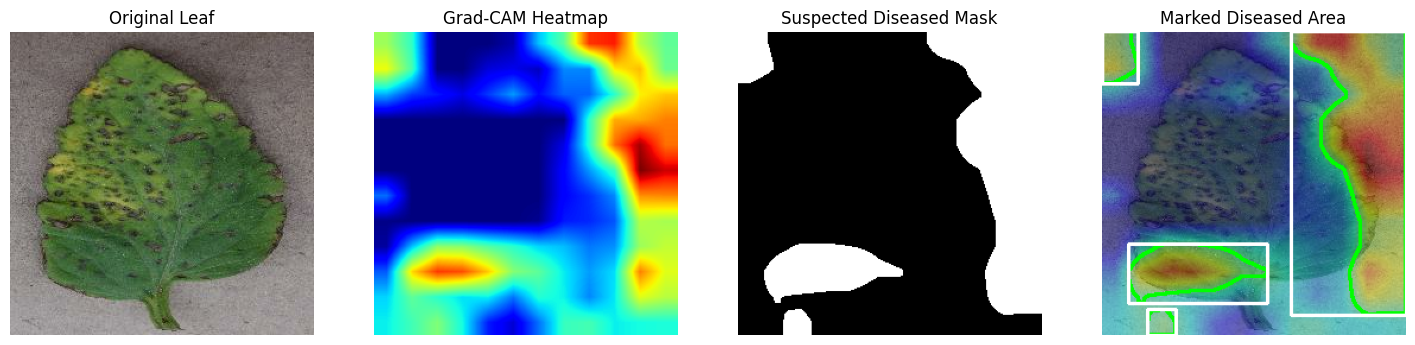

In [22]:
# ============================================================
# 21. Test Grad-CAM marking on one image
# ============================================================

for images_batch, labels_batch in test_ds.take(1):

    image = images_batch[0].numpy().astype("uint8")

    actual_label_idx = labels_batch[0].numpy()
    actual_label = class_names[actual_label_idx]

    result = predict_and_mark_disease_area(
        image=image,
        model=model,
        class_names=class_names,
        threshold=0.45,
        confidence_threshold=0.80
    )

    print("Actual label:    ", actual_label)
    print("Predicted label: ", result["predicted_label"])
    print(f"Confidence:      {result['confidence']:.2f}%")
    
    if result["is_healthy"]:
        print("Status:          ✓ Healthy (No disease marking)")
    elif not result["high_confidence"]:
        print("Status:          ⚠ Low confidence - No marking generated")
    else:
        print("Status:          ⚠ Disease detected with disease area marked")

    # Only show full visualization if we have markings
    if result["heatmap"] is not None:
        plt.figure(figsize=(18, 5))

        plt.subplot(1, 4, 1)
        plt.imshow(result["original_image"])
        plt.title("Original Leaf")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(result["heatmap"], cmap="jet")
        plt.title("Grad-CAM Heatmap")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(result["mask"], cmap="gray")
        plt.title("Suspected Diseased Mask")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(result["marked_image"])
        plt.title("Marked Diseased Area")
        plt.axis("off")

        plt.show()
    else:
        # Simple visualization for healthy or low-confidence predictions
        plt.figure(figsize=(6, 5))
        plt.imshow(result["original_image"])
        if result["is_healthy"]:
            plt.title(f"Healthy\nConfidence: {result['confidence']:.2f}%")
        else:
            plt.title(f"Low Confidence\n{result['predicted_label']}: {result['confidence']:.2f}%")
        plt.axis("off")
        plt.show()

    break

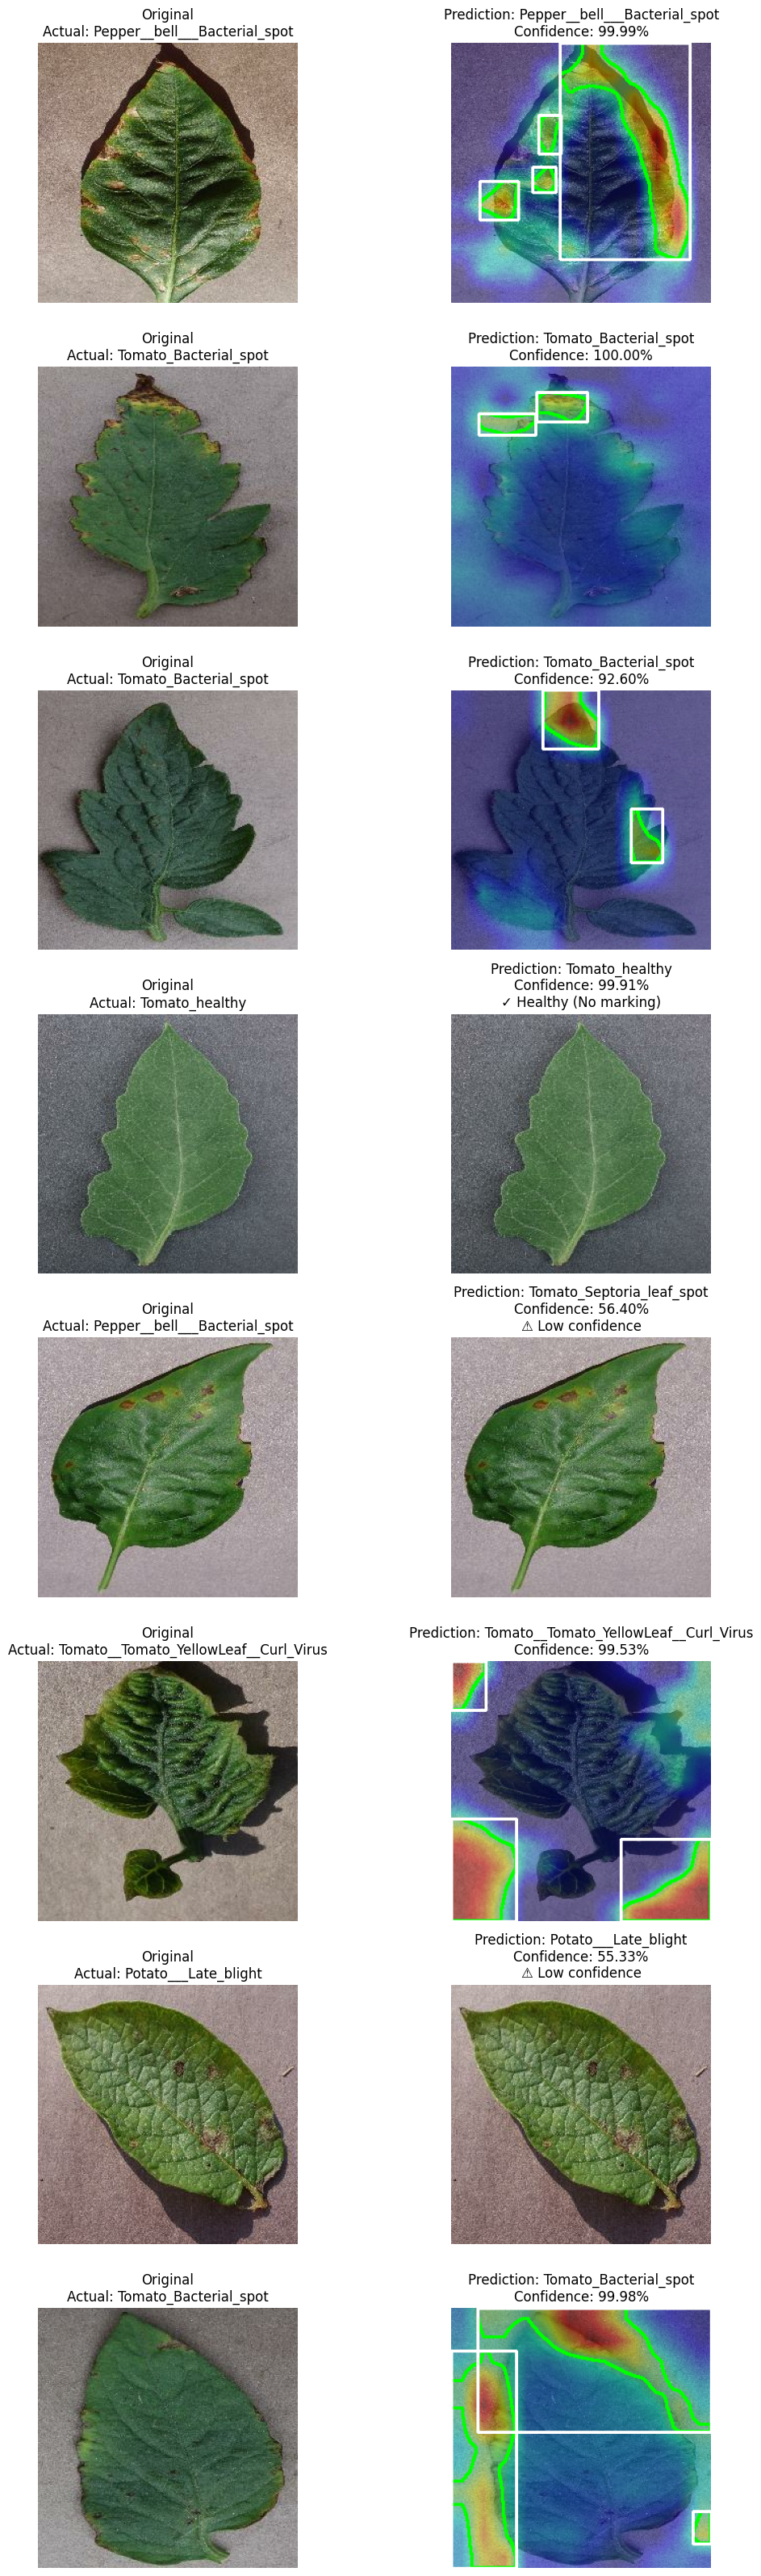

In [52]:
# ============================================================
# 22. Test on multiple images
# ============================================================

def show_multiple_disease_markings(test_ds, model, class_names, total_images=8, threshold=0.45, confidence_threshold=0.80):
    shown = 0

    plt.figure(figsize=(12, total_images * 4))

    for images_batch, labels_batch in test_ds:

        for i in range(len(images_batch)):

            if shown >= total_images:
                plt.tight_layout()
                plt.show()
                return

            image = images_batch[i].numpy().astype("uint8")
            actual_label = class_names[labels_batch[i].numpy()]

            result = predict_and_mark_disease_area(
                image=image,
                model=model,
                class_names=class_names,
                threshold=threshold,
                confidence_threshold=confidence_threshold
            )

            plt.subplot(total_images, 2, shown * 2 + 1)
            plt.imshow(image)
            plt.title(f"Original\nActual: {actual_label}")
            plt.axis("off")

            plt.subplot(total_images, 2, shown * 2 + 2)
            plt.imshow(result["marked_image"])
            
            # Build title based on result
            if result["is_healthy"]:
                title = f"Prediction: {result['predicted_label']}\nConfidence: {result['confidence']:.2f}%\n✓ Healthy (No marking)"
            elif not result["high_confidence"]:
                title = f"Prediction: {result['predicted_label']}\nConfidence: {result['confidence']:.2f}%\n⚠ Low confidence"
            else:
                title = f"Prediction: {result['predicted_label']}\nConfidence: {result['confidence']:.2f}%"
            
            plt.title(title)
            plt.axis("off")

            shown += 1


show_multiple_disease_markings(
    test_ds=test_ds,
    model=model,
    class_names=class_names,
    total_images=8,
    threshold=0.45,
    confidence_threshold=0.80
)

In [24]:
# ============================================================
# 23. Save trained model
# ============================================================

# os.makedirs("./models", exist_ok=True)

# version = len(os.listdir("./models")) + 1

# model.save(f"./models/plant_village_v{version}.keras")

# print(f"Model saved as ./models/plant_village_v{version}.keras")